In [3]:
### Tutorial for PARAFAC2-RISE on scRNA-seq data measured across multiple conditions
from RISE.factorization import pf2
from RISE.imports import import_thomson

# Import your dataset
X = import_thomson()

/home/aramirez/RISE/.venv/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Must be an AnnData object with observations columns *condition_unique_idx* that is 0-indexed and is preprocessed (i.e. doublets removed, genes filtered, normalized, log transformed, etc.). *prepare_dataset* from *parafac2.normalize* was used to prepare the dataset in addition to *doubletdetection*.

100%|██████████| 7/7 [00:35<00:00,  5.00s/it]
/home/aramirez/RISE/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(


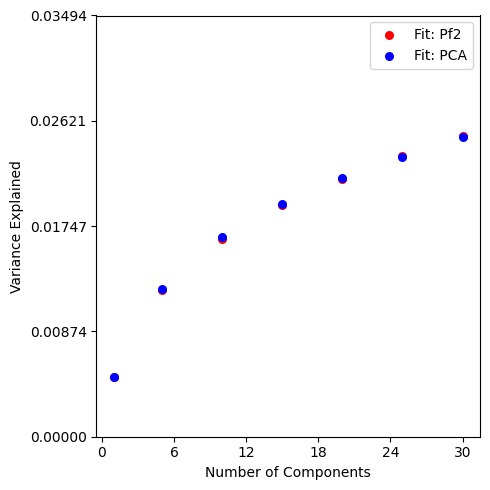

In [4]:
from RISE.figures.commonFuncs.plotGeneral import plot_r2x
%matplotlib inline
import matplotlib.pyplot as plt

ranks = [1, 5, 10, 15, 20, 25, 30]
fig, ax = plt.subplots(figsize=(5, 5))

# Make PR to change Pf2 to RISE and then alter colorlabel bar for all figures
plot_r2x(X, ranks, ax)
plt.tight_layout()
plt.show()

/home/aramirez/RISE/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
 10%|▉         | 49/500 [00:06<01:01,  7.38it/s, R2X=0.0274, error=0.973, jump=5.13, Δ=-4.57e-6]


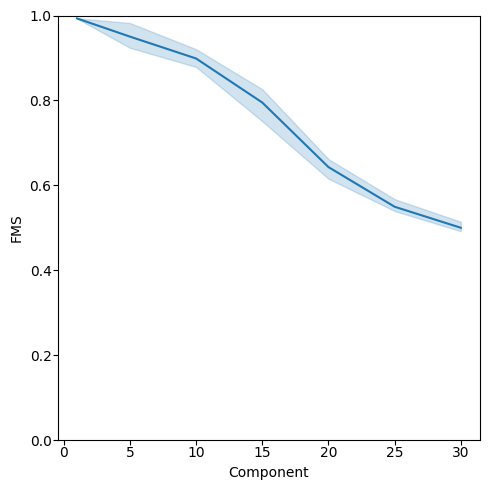

In [5]:
from RISE.figures.figureS4 import plot_fms_diff_ranks
%matplotlib inline

fig, ax = plt.subplots(figsize=(5, 5))

rank_list = list(ranks)

plot_fms_diff_ranks(X, ax, ranksList=rank_list, runs=3)
plt.tight_layout()
plt.show()

Based on the FMS across components, we can choose a rank of 20 to continue with the analysis. We want FMS to be above ~0.6.

In [6]:
# Perform factorization
rank = 20
X = pf2(X=X, rank=rank, doEmbedding=True, tolerance=1e-9, max_iter=500, random_state=42)

 10%|▉         | 49/500 [00:05<00:52,  8.67it/s, R2X=0.0214, error=0.979, jump=5.13, Δ=-1.78e-6]
/home/aramirez/RISE/.venv/lib/python3.12/site-packages/pacmap/pacmap.py:822: UserWarning: Warning: random state is set to 42
  warnings.warn(f'Warning: random state is set to {_RANDOM_STATE}')


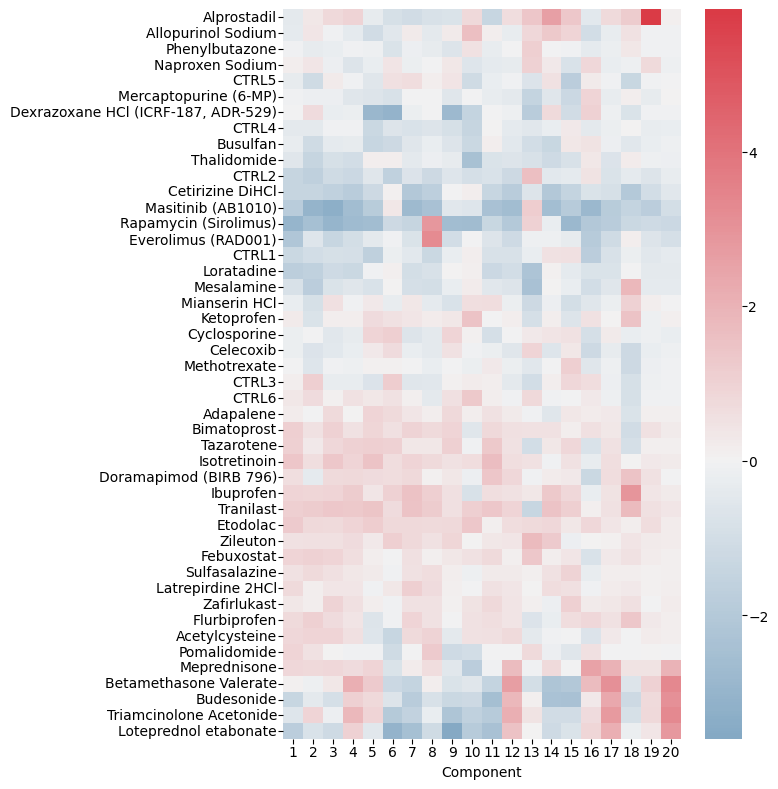

In [17]:
# Plot condition factors
from RISE.figures.commonFuncs.plotFactors import plot_condition_factors
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 8))
# Log transform the condition factors for better visualization
plot_condition_factors(X, ax=ax, cond="Condition", log_transform=True)
plt.tight_layout()
plt.show()

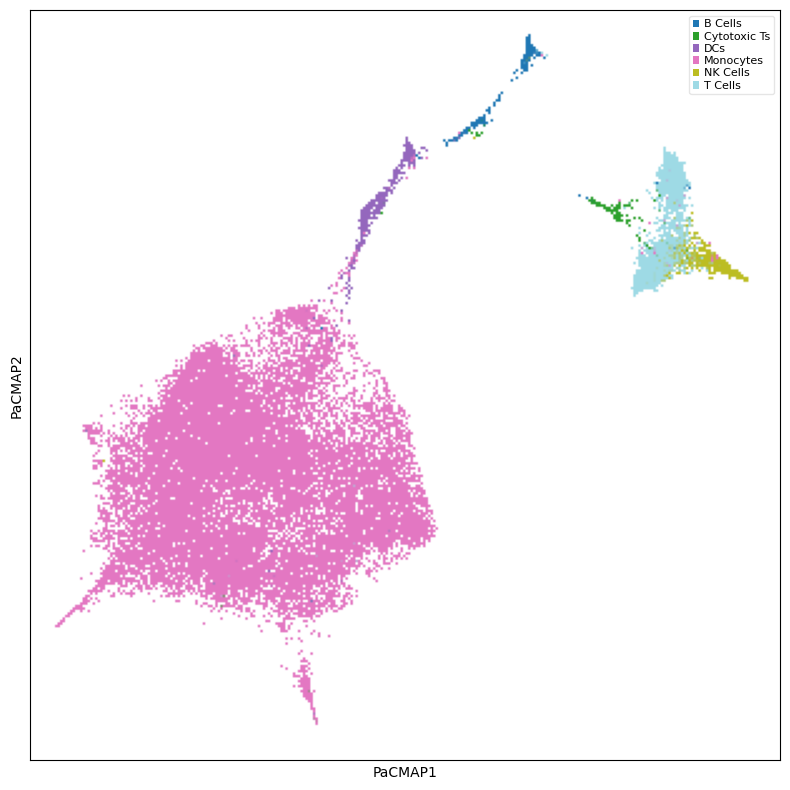

In [8]:
# Plot projection-based cell embedding with cell type labels
from RISE.figures.commonFuncs.plotPaCMAP import plot_labels_pacmap
%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 8))

plot_labels_pacmap(X, labelType="Cell Type", ax=ax)
plt.tight_layout()
plt.show()

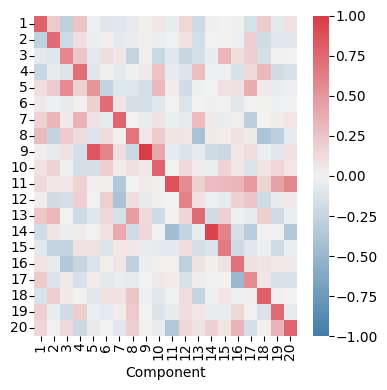

In [9]:
# Plot eigen-state factors
from RISE.figures.commonFuncs.plotFactors import plot_eigenstate_factors
%matplotlib inline
fig, ax = plt.subplots(figsize=(4, 4))

plot_eigenstate_factors(X, ax=ax)
plt.tight_layout()
plt.show()

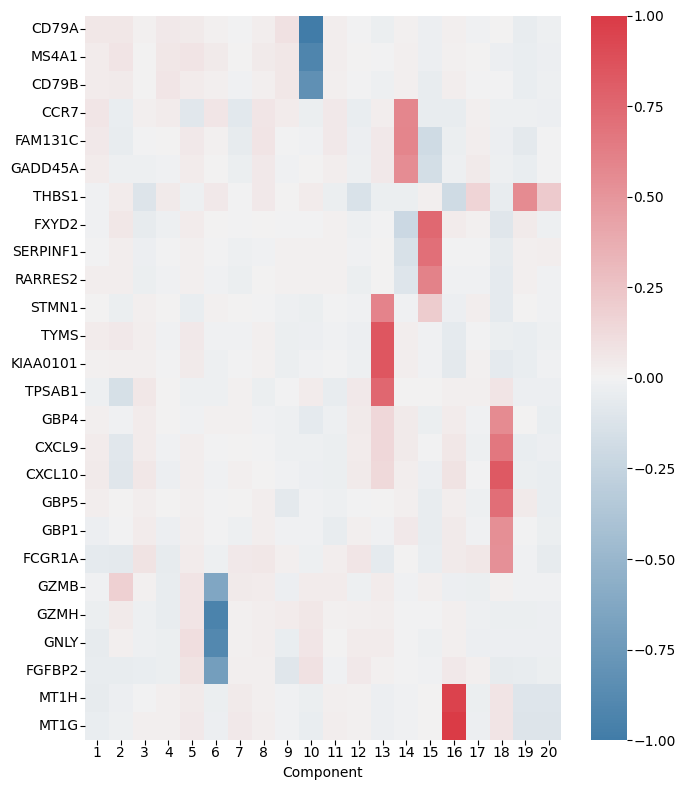

In [14]:
# Plot gene factors
from RISE.figures.commonFuncs.plotFactors import plot_gene_factors
%matplotlib inline
fig, ax = plt.subplots(figsize=(7, 8))

# Higher trim weight value, more genes will be trimmed
plot_gene_factors(X, ax=ax, weight=0.2, trim=True)
plt.tight_layout()
plt.show()

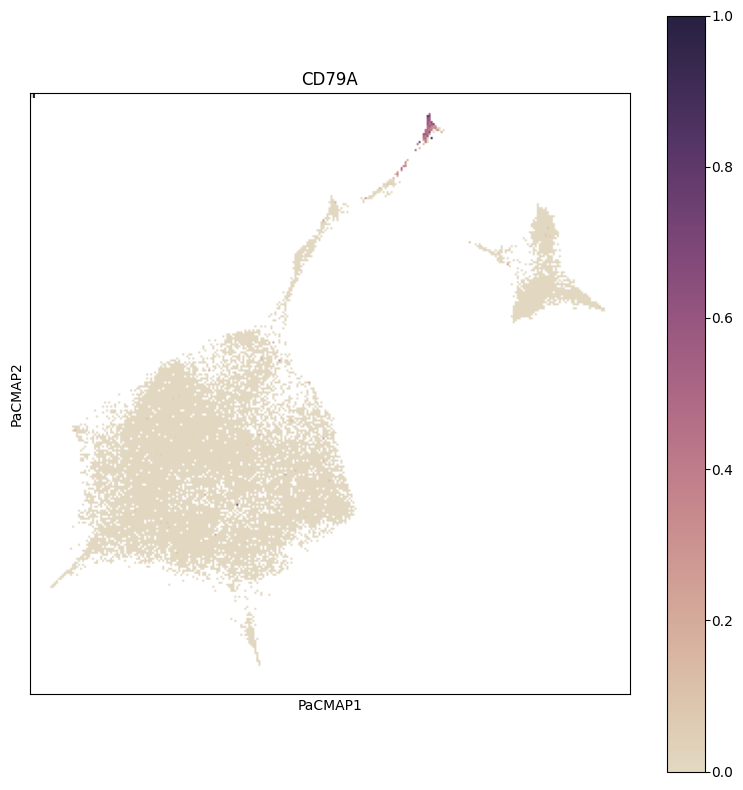

In [15]:
# Plot gene weights overlayed on projection cell embedding
from RISE.figures.commonFuncs.plotPaCMAP import plot_gene_pacmap

fig, ax = plt.subplots(figsize=(8, 8))

gene = "CD79A"  # Example gene, you can change this to any gene of interest
plot_gene_pacmap(gene, X, ax=ax, clip_outliers=0.9995)
plt.tight_layout()
plt.show()

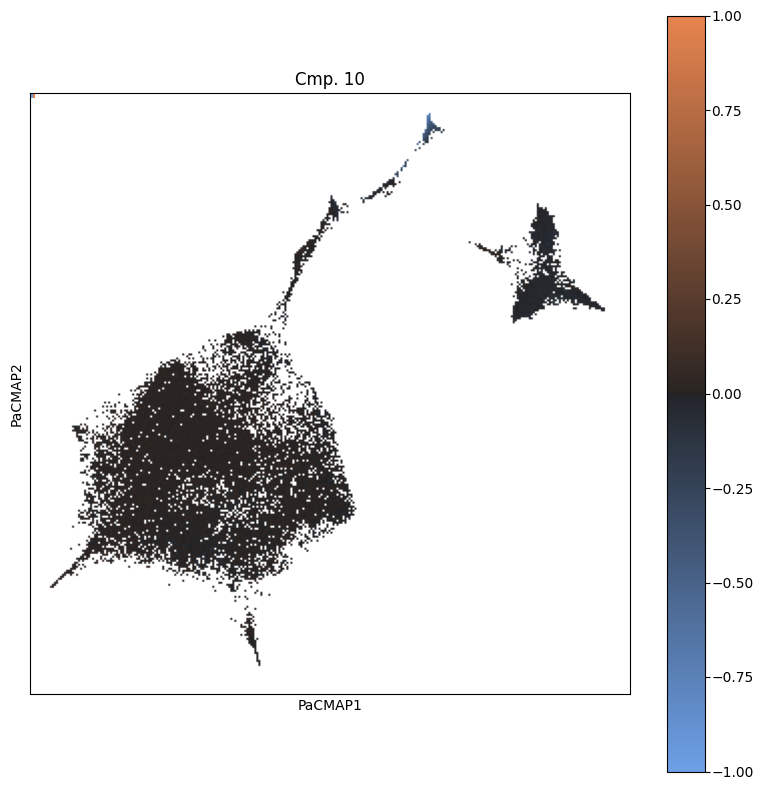

In [16]:
# Plot weighted projections for one component
from RISE.figures.commonFuncs.plotPaCMAP import plot_wp_pacmap

fig, ax = plt.subplots(figsize=(8, 8))

plot_wp_pacmap(X, cmp=10, ax=ax)
plt.tight_layout()
plt.show()

# You can also plot the weighted projections broken down by cell type 
# for better visualization and interpretation